In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import matplotlib.pyplot as plt

seed = 52

CWD = os.getcwd()
DATA_PATH = os.path.join(CWD, '10X_multiome_mouse_brain.loom')
CELLANNO_PATH = os.path.join(CWD, 'cell_annotations.tsv')

In [2]:
# Load data
adata =sc.read_loom(DATA_PATH)
adata.var_names_make_unique()
adata.obs_names = [obs.split(':')[1][:-1] + '-1' for obs in adata.obs_names]

In [3]:
# Load cell annotations from Multivelo 
cell_annot = pd.read_csv(CELLANNO_PATH, sep='\t', index_col=0)
adata = adata[cell_annot.index,:]
adata.obs['celltype'] = cell_annot['celltype']

In [4]:
# Preprocessing
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'],log1p=False, percent_top=None, inplace=True)
lower, upper = np.percentile(adata.obs.n_genes_by_counts, [2,98]).astype(int)
print(f'Retaining cells with {lower} < n_genes_by_counts < {upper}')
sc.pp.filter_cells(adata, min_genes=lower)
sc.pp.filter_cells(adata, max_genes=upper)
scv.pp.filter_and_normalize(adata, min_shared_counts=10, n_top_genes=2000, subset_highly_variable=False) 
scv.pp.moments(adata, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata, random_state=seed)

Retaining cells with 767 < n_genes_by_counts < 3979
Filtered out 21769 genes that are detected 10 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.


c:\Users\aless\Desktop\scVEMO\lib\site-packages\scvelo\preprocessing\utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


computing neighbors
    finished (0:00:10) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:03) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [15]:
# Da Letteratura
markers = {
    'Interneurons': ['Dlx1', 'Dlx2', 'Lhx6', 'Adarb2', 'Dlx5'], #'Cdc17',
    'Cajal-Retzius': ['Reln', 'Trp73', 'Lhx5'], #'Lhx1',
    'Deep Layer': [ 'Fezf2', 'Tfap2d', 'Neurod6'], #'Bclb1b'
    'Upper Layer': ['Satb2',  'Nrgn', 'Dok5'],  #Pou3f1',
    'SVZ' : ['Eomes', 'Sema3c', 'Neurod1', 'Calb2', 'Neurod6'], 
    'RG' : [ 'Pax6', 'Ednrb', 'Nes', 'Neurod6', 'Vim'], #'Hes1', 'Hes5','Sox4'
    'Astrocytes': [ 'Aldh1l1',], #Aqp4' , 'Gfap',  'Hes5'
    'OPC': ['Olig2', 'Pdgfra', 'Lpar1'], #'Olig1',
    'Microglia': ['Trem2', 'Satb2'], #Tme119'
    'Ependymal': ['Rfx4','Ednrb', 'Stat3'], #'Foxj1 'T4msf1'
    'IPC' : ['Cdk4', 'Igfbpl1', 'Top2a', 'Eomes'] #'Sox4, 'Sox11'
}

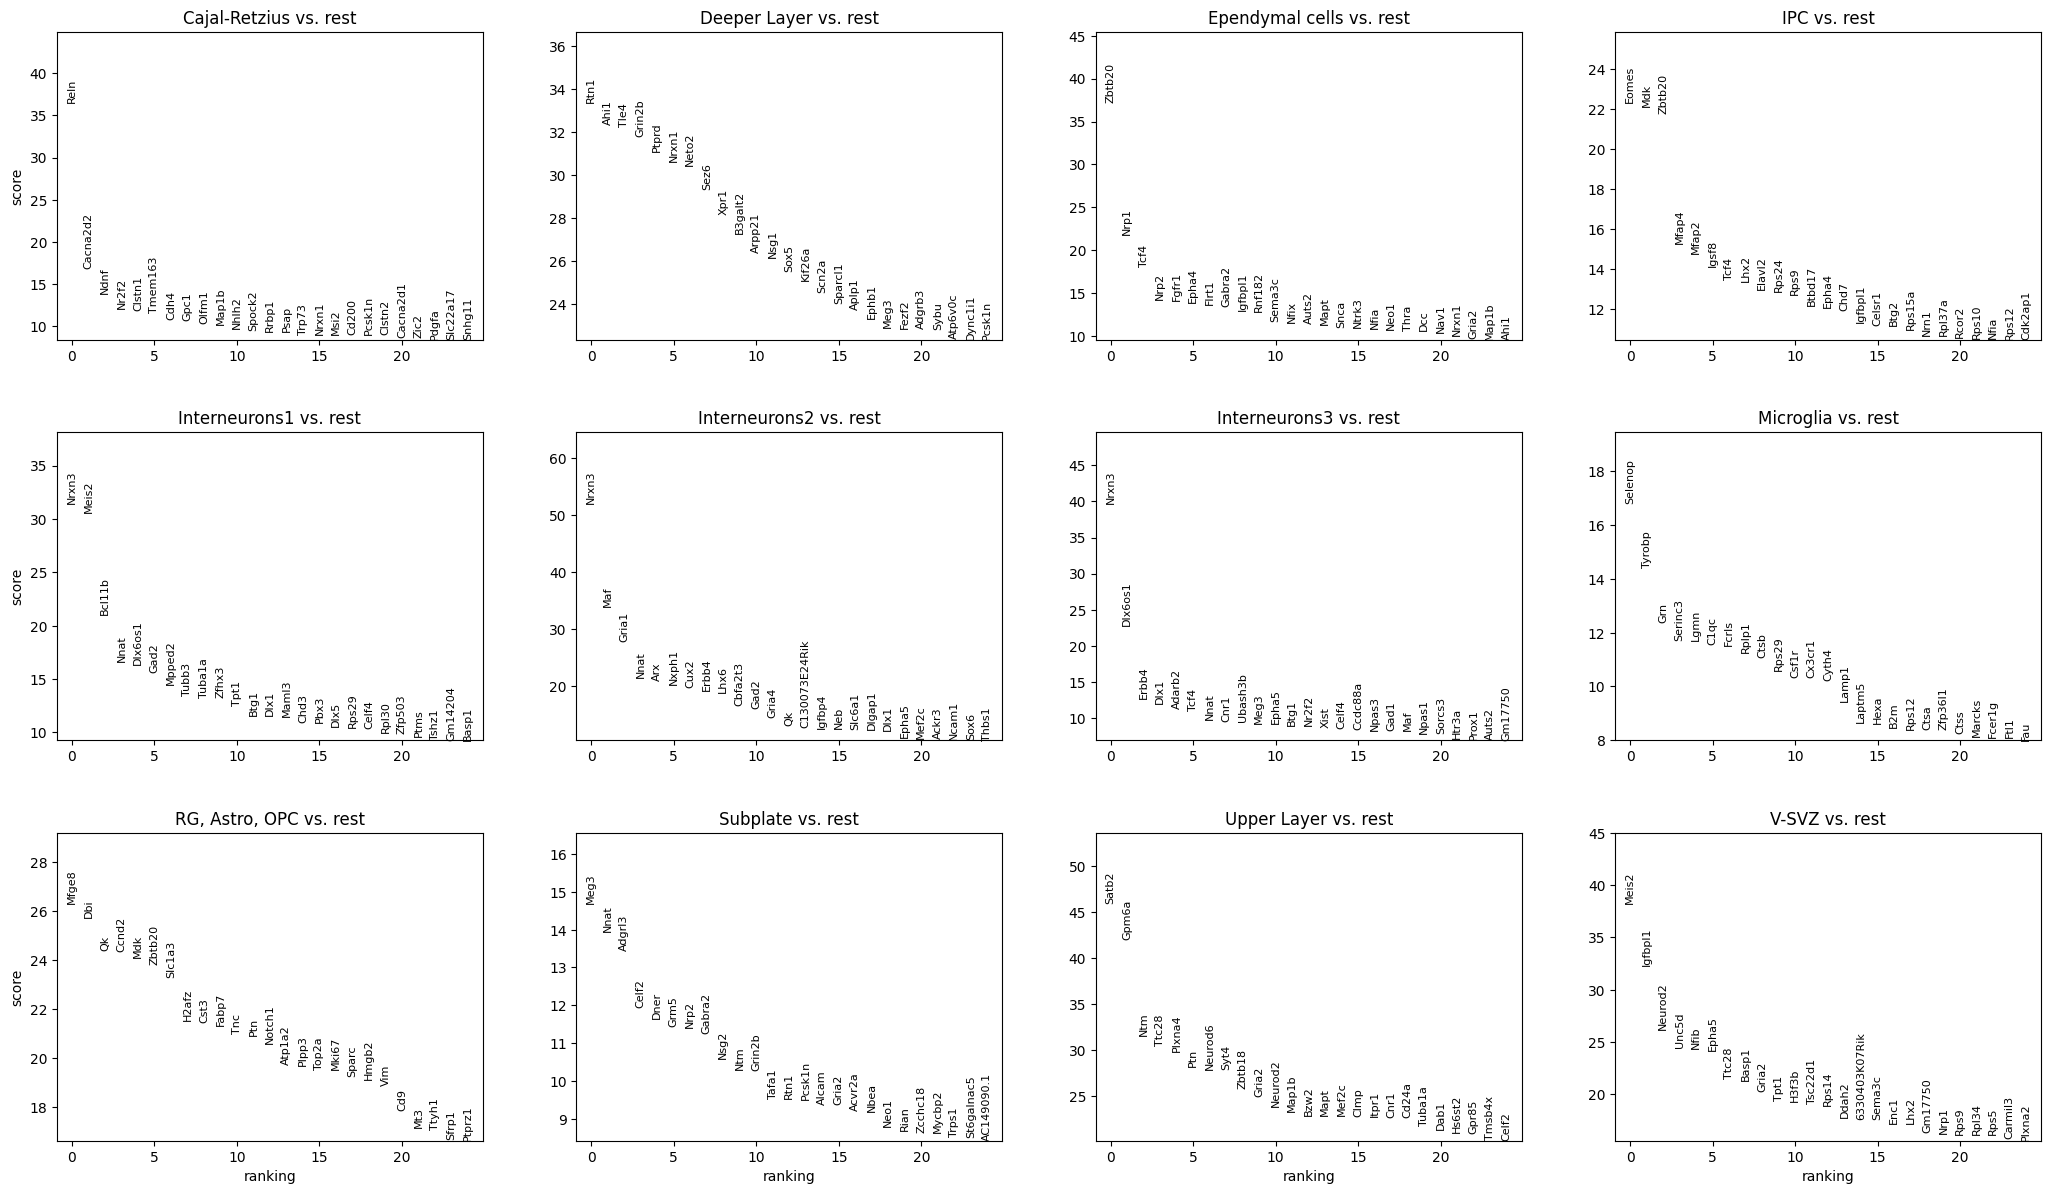

In [7]:
sc.tl.rank_genes_groups(adata, 'celltype')
sc.pl.rank_genes_groups(adata, n_genes=25, sharey=False)

In [8]:
# Salvo un df con i 5 top expressed genes
ranked_genes = adata.uns['rank_genes_groups']
groups= ranked_genes['names'].dtype.names
groups = pd.DataFrame(
    {group + '_' + key[:1]: ranked_genes[key][group]
    for group in groups for key in ['names']}).head(5)
groups


,Cajal-Retzius_n,Deeper Layer_n,Ependymal cells_n,IPC_n,Interneurons1_n,Interneurons2_n,Interneurons3_n,Microglia_n,"RG, Astro, OPC_n",Subplate_n,Upper Layer_n,V-SVZ_n
0,Reln,Rtn1,Zbtb20,Eomes,Nrxn3,Nrxn3,Nrxn3,Selenop,Mfge8,Meg3,Satb2,Meis2
1,Cacna2d2,Ahi1,Nrp1,Mdk,Meis2,Maf,Dlx6os1,Tyrobp,Dbi,Nnat,Gpm6a,Igfbpl1
2,Ndnf,Tle4,Tcf4,Zbtb20,Bcl11b,Gria1,Erbb4,Grn,Qk,Adgrl3,Ntm,Neurod2
3,Nr2f2,Grin2b,Nrp2,Mfap4,Nnat,Nnat,Dlx1,Serinc3,Ccnd2,Celf2,Ttc28,Unc5d
4,Clstn1,Ptprd,Fgfr1,Mfap2,Dlx6os1,Arx,Adarb2,Lgmn,Mdk,Dner,Plxna4,Nfib


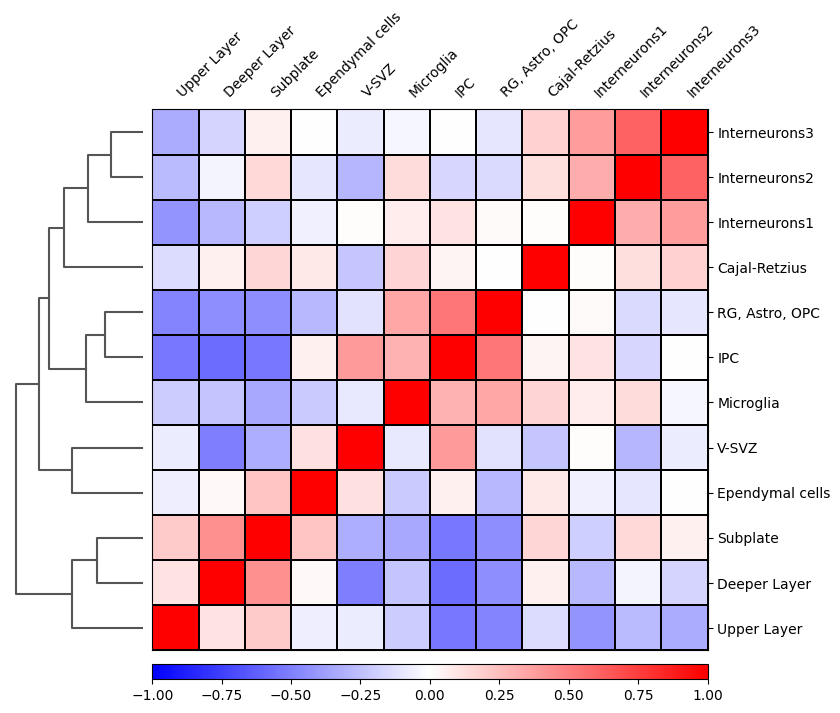

In [9]:
sc.pl.correlation_matrix(adata, 'celltype', save='_loom_cluters.png')

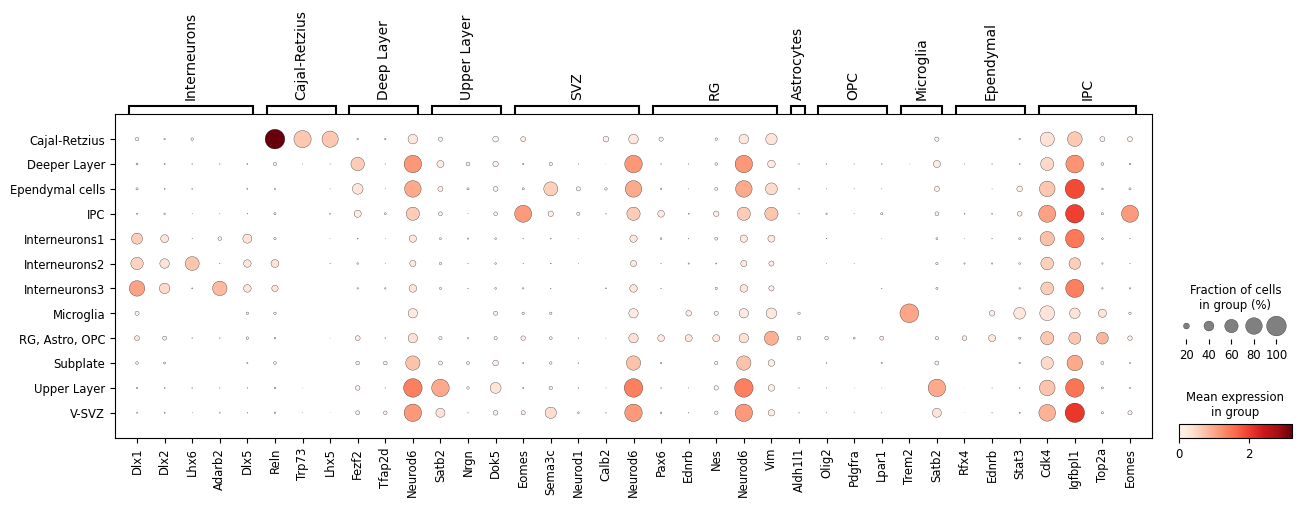

In [17]:
sc.pl.dotplot(adata, markers, 'celltype', save='DEA_dotPlot_litterature.png')

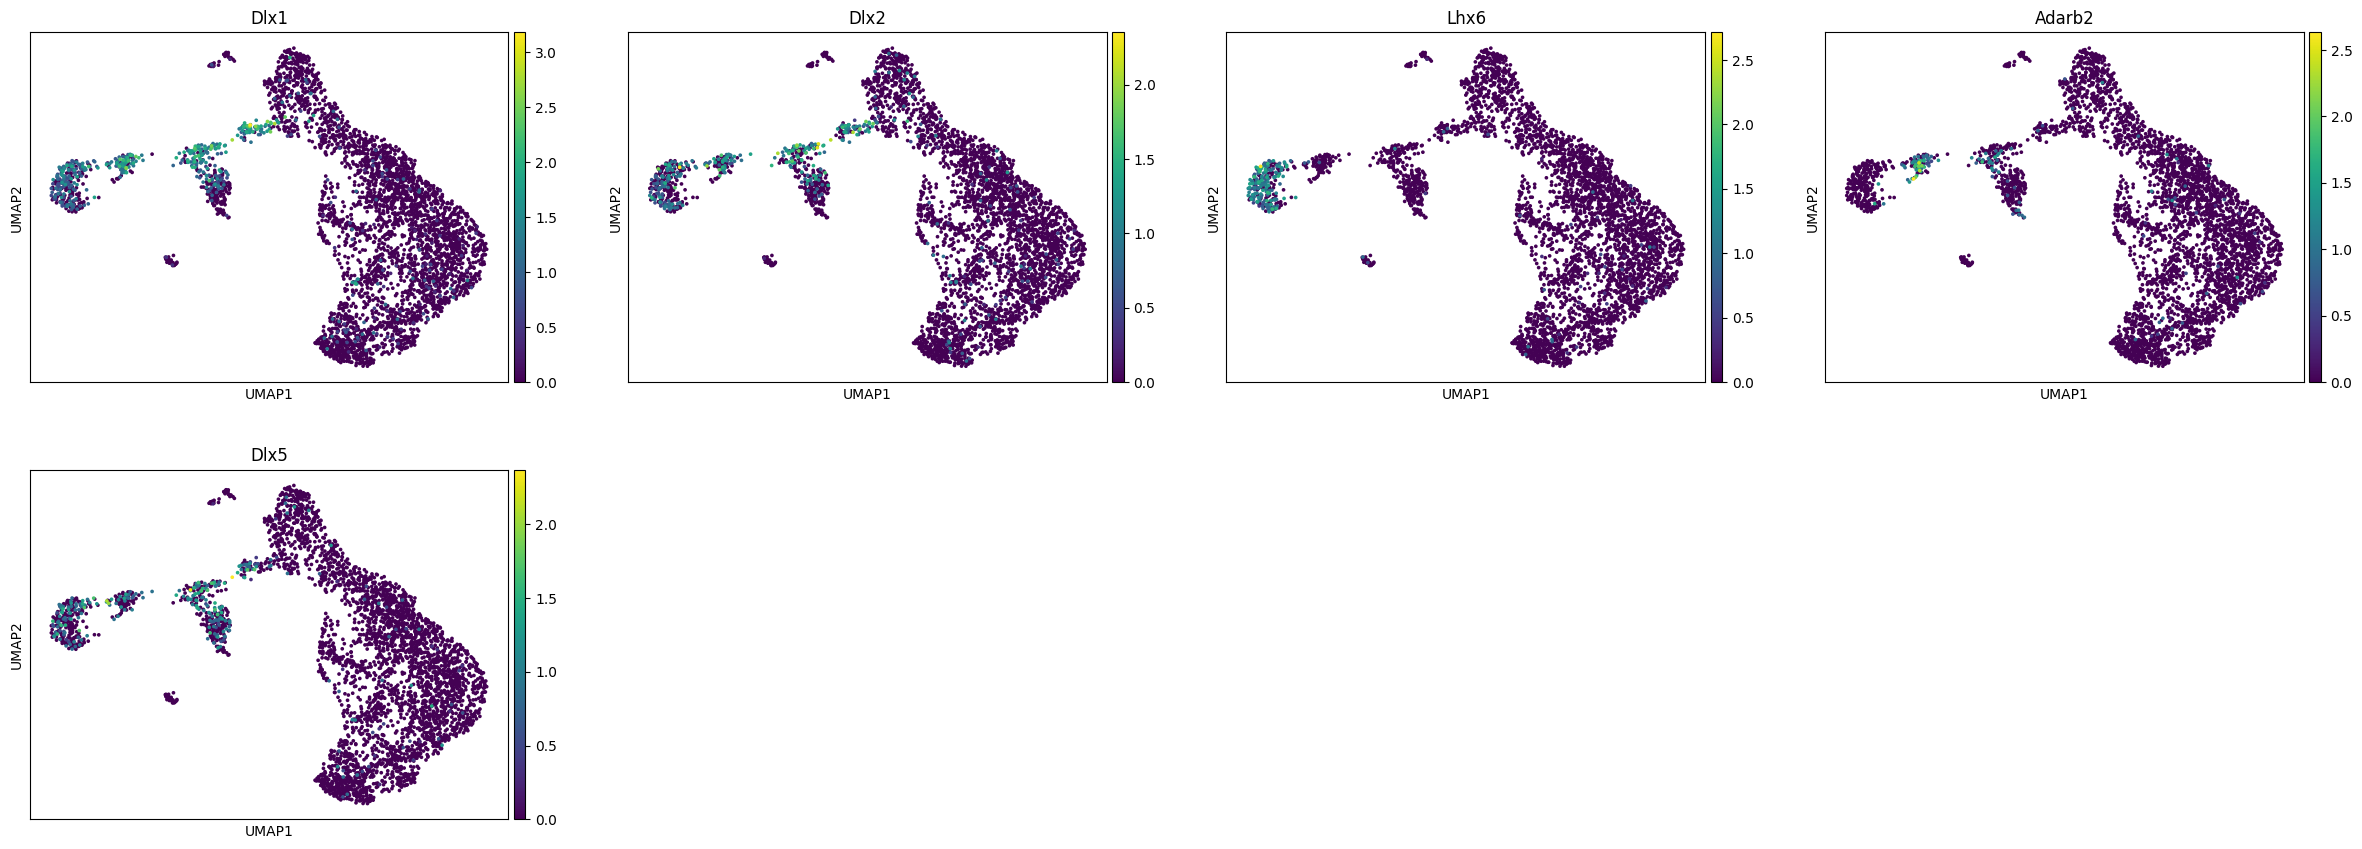

In [18]:
sc.pl.umap(adata, color=markers['Interneurons'], save ='interneurons.pgn')

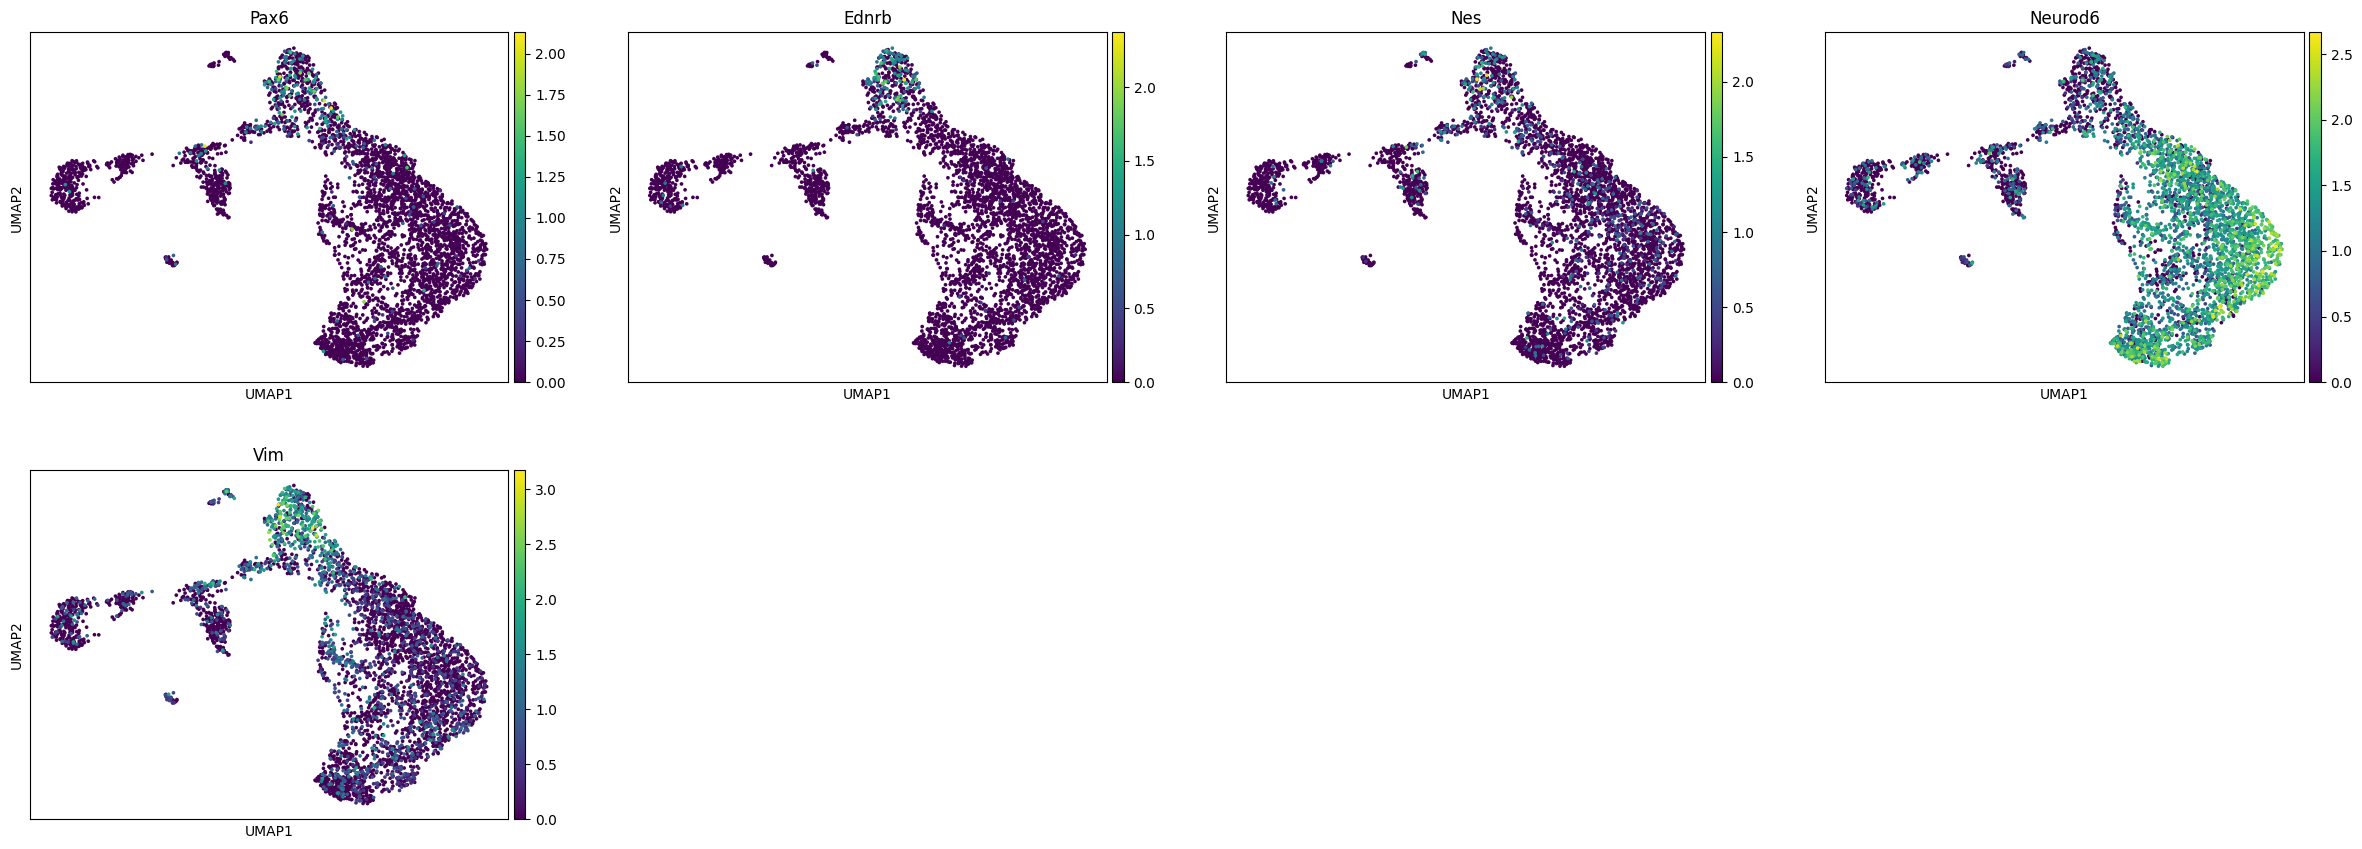

In [19]:
sc.pl.umap(adata, color=markers['RG'], save ='RG.png')

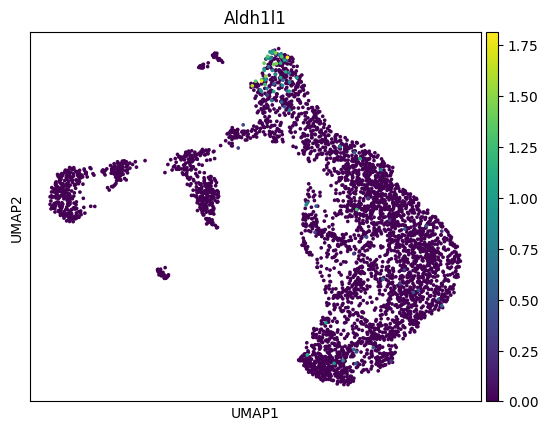

In [20]:
sc.pl.umap(adata, color=markers['Astrocytes'], save='astro.png')

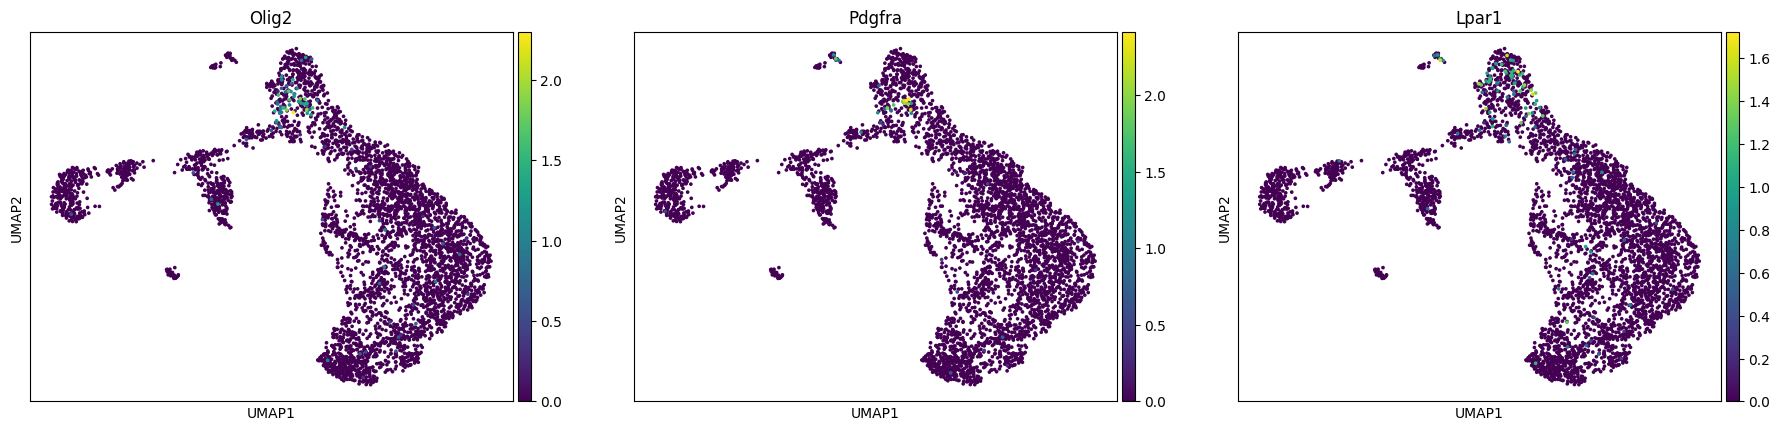

In [21]:
sc.pl.umap(adata, color=markers['OPC'], save='opc.png')

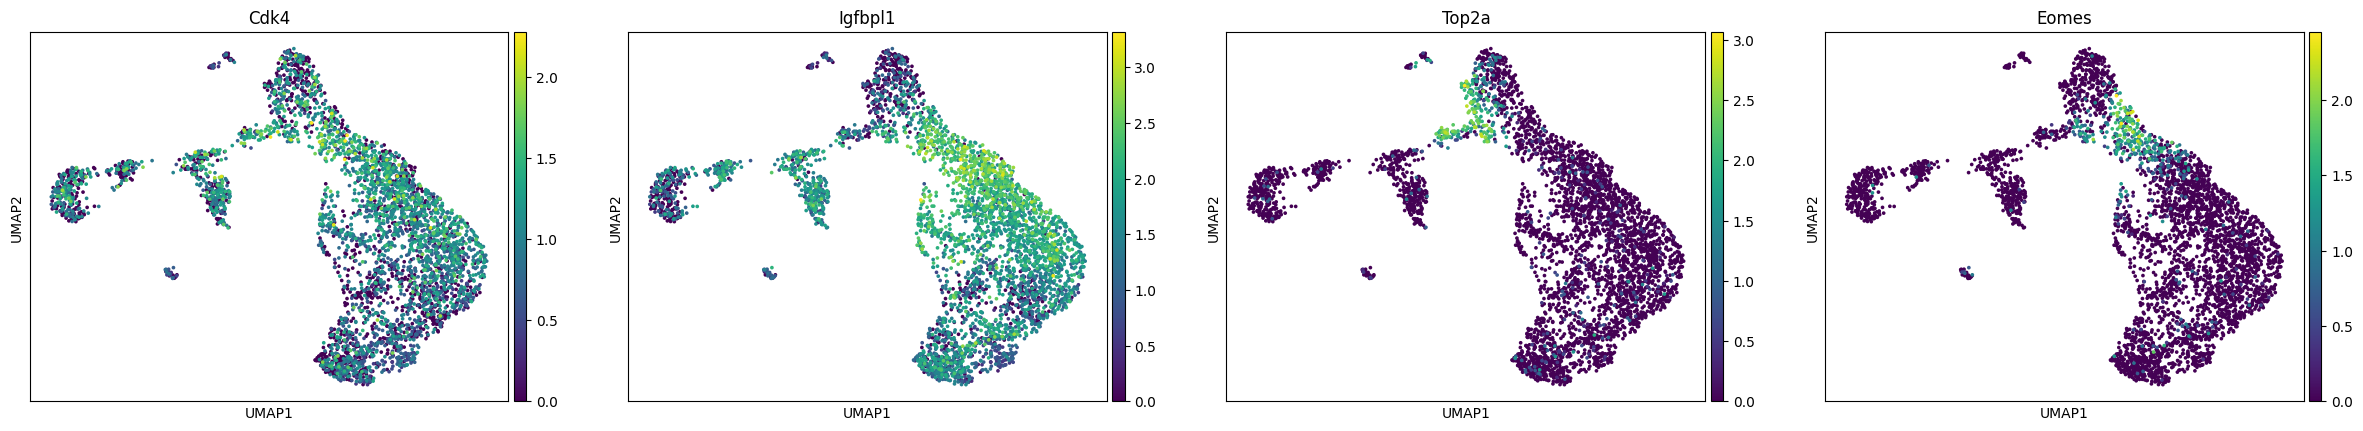

In [22]:
sc.pl.umap(adata, color=markers['IPC'], save = 'ipc.png')

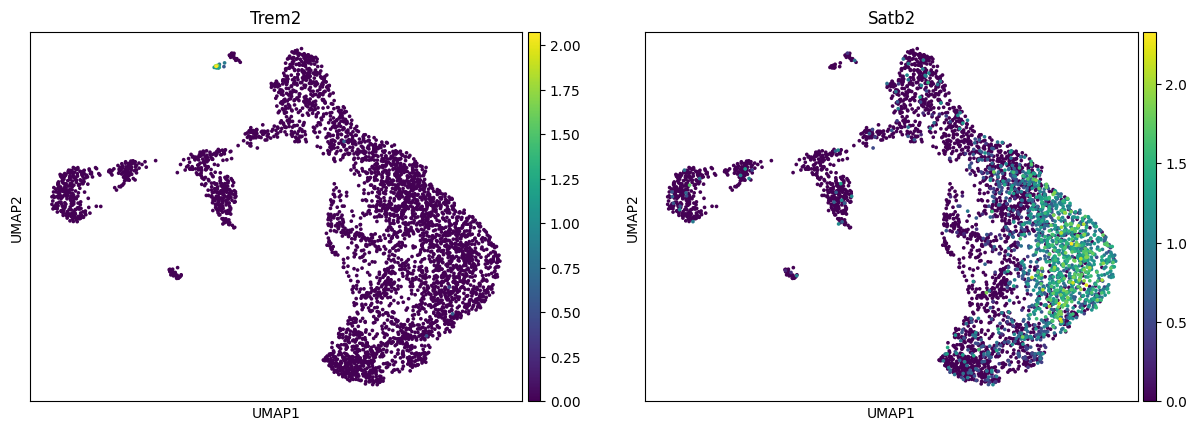

In [23]:
sc.pl.umap(adata, color=markers['Microglia'], save = 'microglia.png')

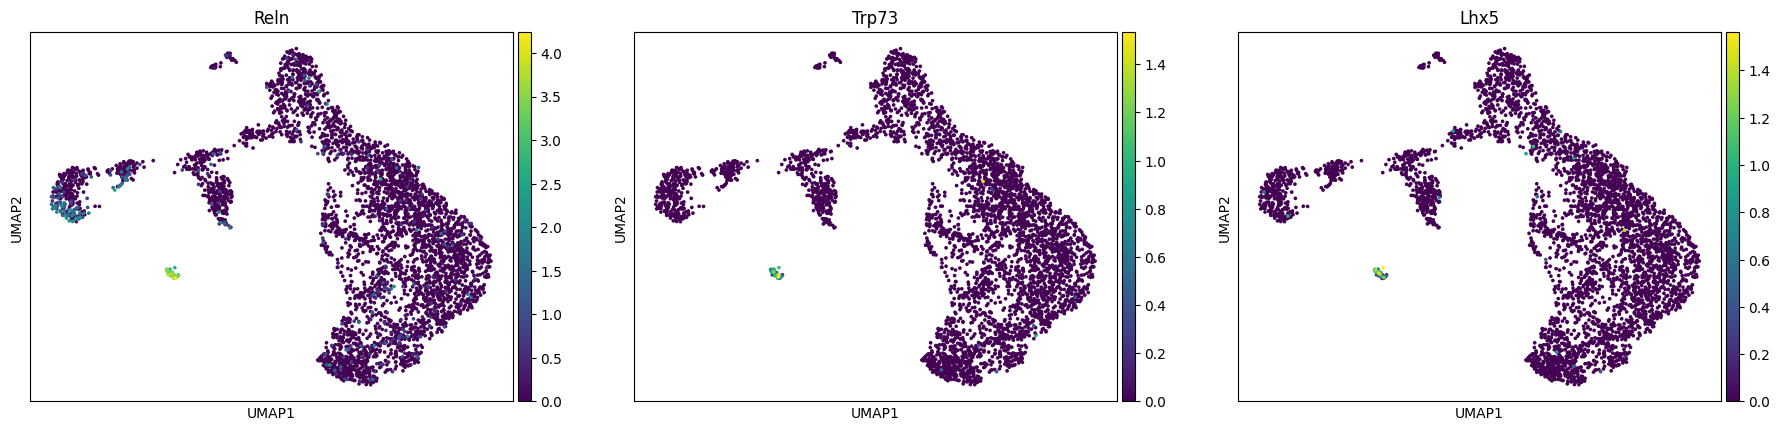

In [24]:
sc.pl.umap(adata, color=markers['Cajal-Retzius'], save = 'calrez.png')

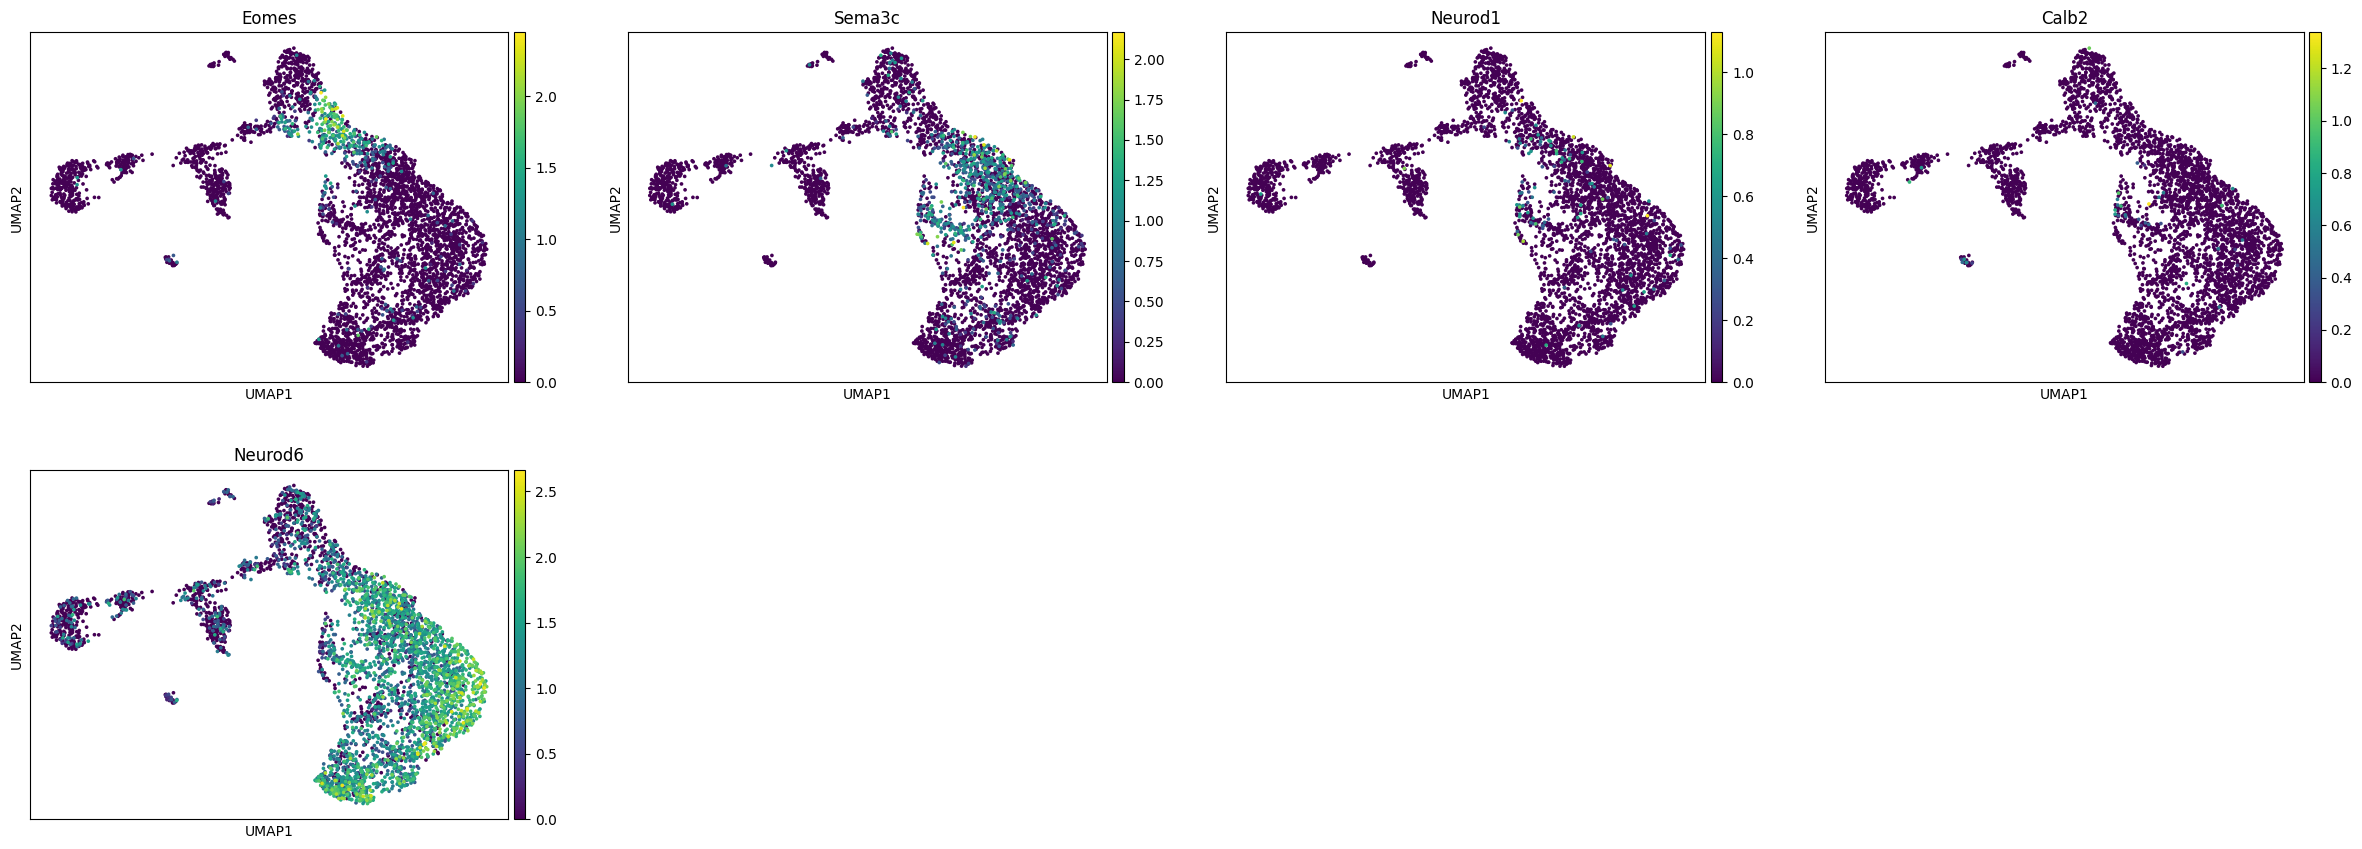

In [25]:
sc.pl.umap(adata, color=markers['SVZ'], save = 'svz.png')

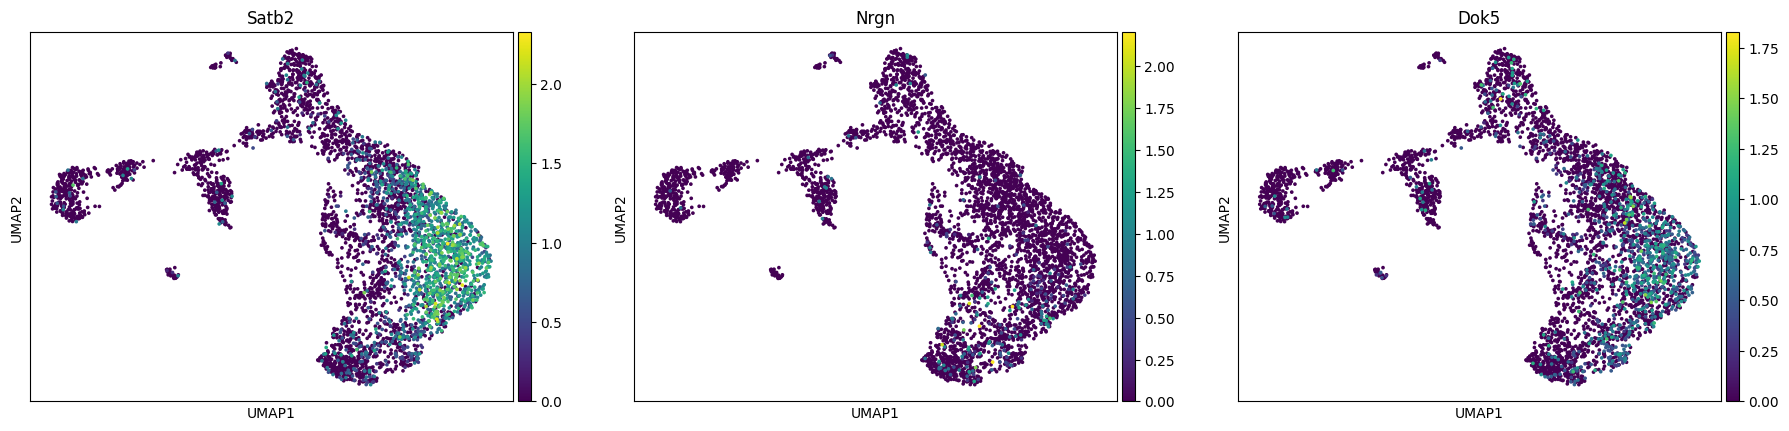

In [26]:
sc.pl.umap(adata, color=markers['Upper Layer'], save = 'uLayer.png')

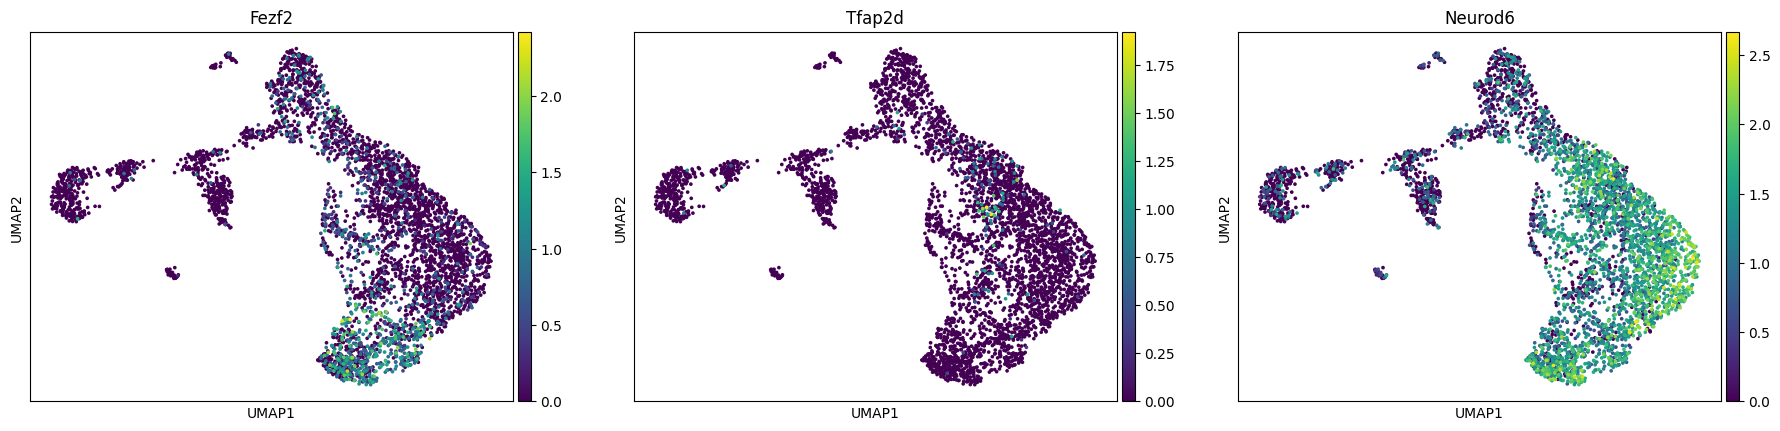

In [28]:
sc.pl.umap(adata, color=markers['Deep Layer'], save = 'dLayer.png')

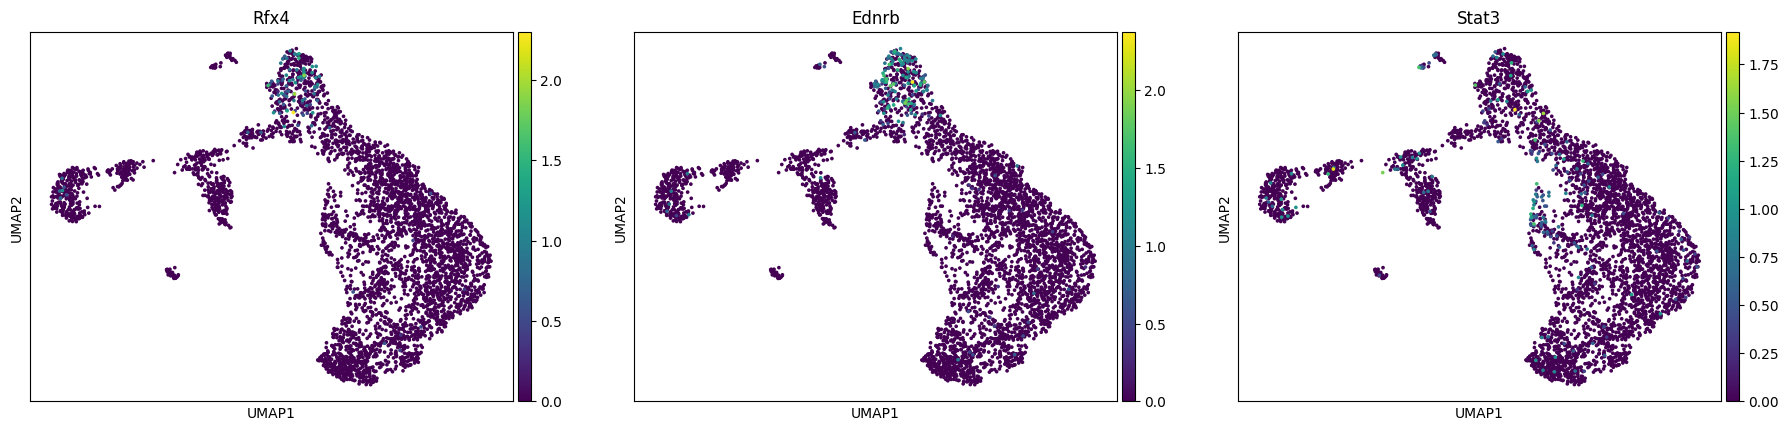

In [29]:
sc.pl.umap(adata, color=markers['Ependymal'], save = 'epen.png')